# Regresión Lineal Bayesiana

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
from scipy.stats import gaussian_kde
import plotly.graph_objects as go
import arviz as az
import pymc as pm


## Modelo clásico de regresión

Intercepto (β0): 82.40150493202349
Pendiente (β1): -18.523778608296922


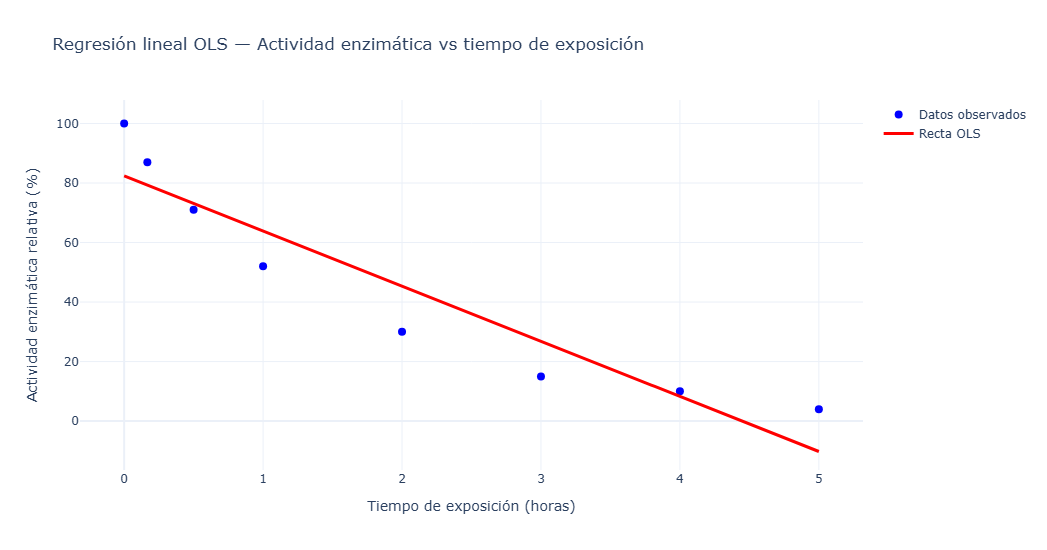

In [1]:
#Datos del ejercicio
X = np.array([0, 0.167, 0.500, 1, 2, 3, 4, 5], dtype=float).reshape(-1, 1)
y = np.array([100, 87, 71, 52, 30, 15, 10, 4], dtype=float)

#Implemeteción del modelo clasico
modelo_clasico = LinearRegression()
modelo_clasico.fit(X, y)

print("Intercepto (β0):", modelo_clasico.intercept_)
print("Pendiente (β1):", modelo_clasico.coef_[0])

x_grid = np.linspace(0, 5, 200).reshape(-1, 1)
y_pred = modelo_clasico.predict(x_grid)

# Gráfica con Plotly
fig = go.Figure()

# Datos observados
fig.add_trace(go.Scatter(
    x=X.flatten(),
    y=y,
    mode='markers',
    name='Datos observados',
    marker=dict(size=8, color='blue')
))

# Recta OLS
fig.add_trace(go.Scatter(
    x=x_grid.flatten(),
    y=y_pred,
    mode='lines',
    name='Recta OLS',
    line=dict(color='red', width=3)
))

fig.update_layout(
    title="Regresión lineal OLS — Actividad enzimática vs tiempo de exposición",
    xaxis_title="Tiempo de exposición (horas)",
    yaxis_title="Actividad enzimática relativa (%)",
    template="plotly_white",
    width=900,
    height=550
)

fig.show()

## Modelo Bayesiano de Regresión

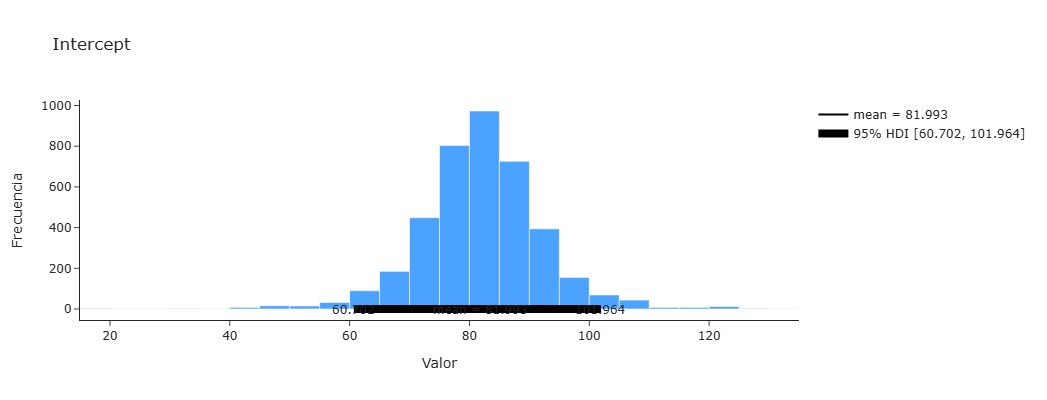

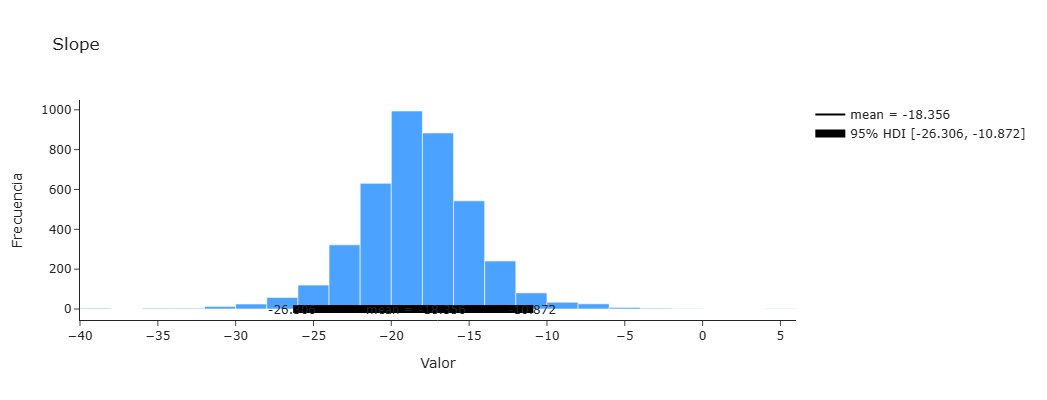

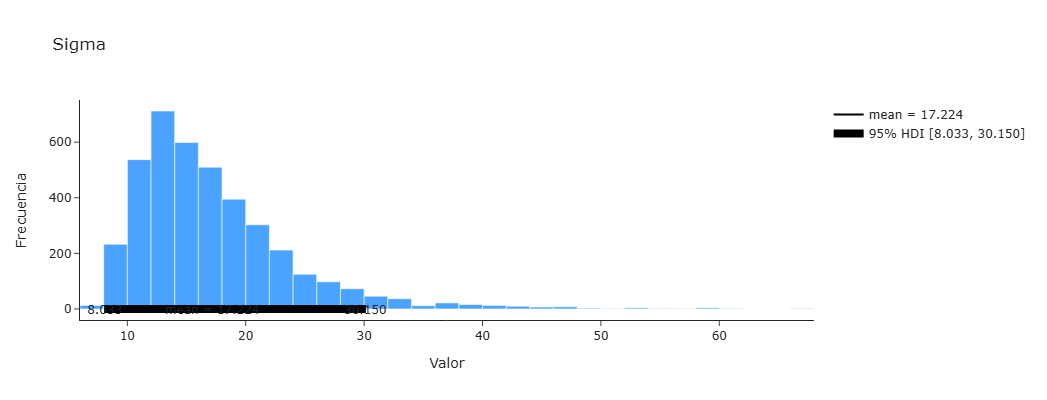

In [6]:
# Extraer valores posteriores
alpha_post = trace_full.posterior["Intercept"].values.flatten()
beta_post  = trace_full.posterior["Slope"].values.flatten()
sigma_post = trace_full.posterior["Sigma"].values.flatten()


# Graficar
def plot_hist_plotly(samples, title):
    mean_val = np.mean(samples)
    hpd_low, hpd_high = az.hdi(samples, hdi_prob=0.95)

    hist = go.Histogram(
        x=samples,
        nbinsx=40,
        marker=dict(color="rgba(0, 123, 255, 0.7)"),
        showlegend=False
    )

    # Línea de media
    mean_line = go.Scatter(
        x=[mean_val, mean_val],
        y=[0, 1],
        mode="lines",
        line=dict(color="black", width=2),
        name=f"mean = {mean_val:.3f}",
        showlegend=True
    )

    # Línea HDI (barra negra)
    hdi_line = go.Scatter(
        x=[hpd_low, hpd_high],
        y=[0, 0],
        mode="lines",
        line=dict(color="black", width=8),
        name=f"95% HDI [{hpd_low:.3f}, {hpd_high:.3f}]",
        showlegend=True
    )

    # Números en los extremos del HDI
    annotations = [
        dict(x=hpd_low, y=-0.02, text=f"{hpd_low:.3f}", showarrow=False),
        dict(x=hpd_high, y=-0.02, text=f"{hpd_high:.3f}", showarrow=False),
        dict(x=mean_val, y=0.9, text=f"mean = {mean_val:.3f}", showarrow=False)
    ]

    fig = go.Figure(data=[hist, mean_line, hdi_line])

    fig.update_layout(
        title=title,
        xaxis_title="Valor",
        yaxis_title="Frecuencia",
        template="simple_white",
        annotations=annotations,
        width=600,
        height=400
    )

    fig.show()

# Graficar cada parámetro
plot_hist_plotly(alpha_post, "Intercept")
plot_hist_plotly(beta_post, "Slope")
plot_hist_plotly(sigma_post, "Sigma")


OLS β0: 82.40150493202349
OLS β1: -18.523778608296922


C:\Users\rolg0\anaconda3\envs\MSA\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning:


Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 127 seconds.
There were 26 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


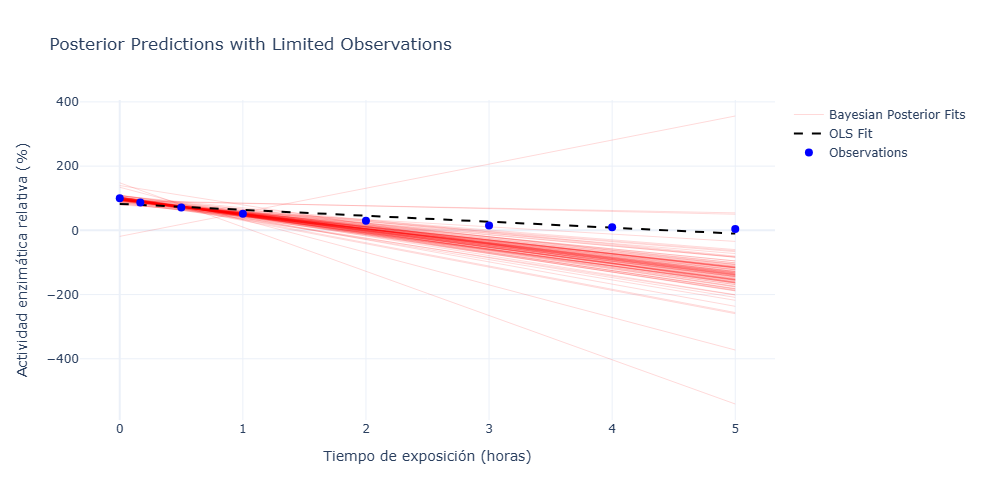

C:\Users\rolg0\anaconda3\envs\MSA\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning:


Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 108 seconds.


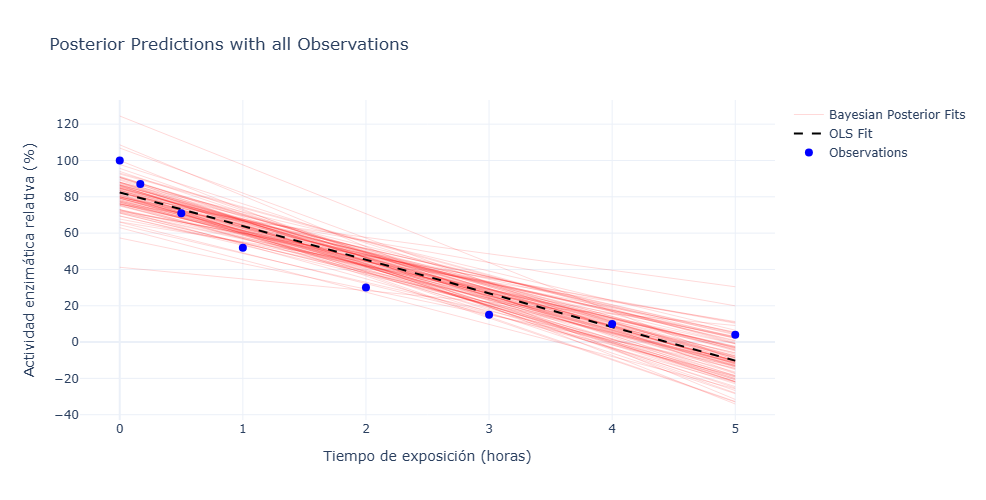

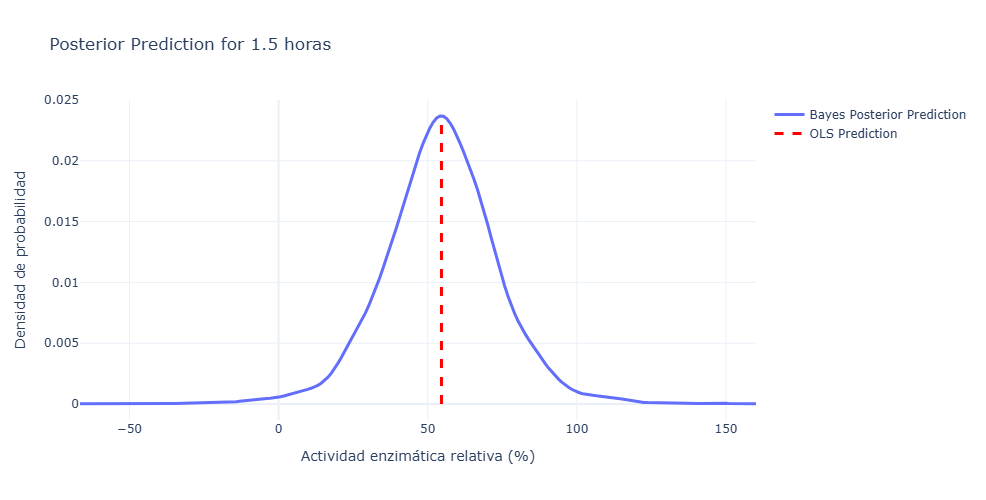

In [7]:
#datos del ejercicio, otra vez 
x = np.array([0, 0.167, 0.500, 1, 2, 3, 4, 5], dtype=float)
y = np.array([100, 87, 71, 52, 30, 15, 10, 4], dtype=float)

X = x.reshape(-1, 1)

# Ajuste OLS 
ols = LinearRegression()
ols.fit(X, y)

beta0_ols = ols.intercept_
beta1_ols = ols.coef_[0]

x_grid = np.linspace(0, 5, 200)
y_ols_grid = beta0_ols + beta1_ols * x_grid

print("OLS β0:", beta0_ols)
print("OLS β1:", beta1_ols)

# BAYES CON POCOS DATOS
idx_small = np.arange(4)  
x_small = x[idx_small]
y_small = y[idx_small]

with pm.Model() as model_small:
    alpha = pm.Normal("alpha", mu=0, sigma=100)
    beta  = pm.Normal("beta",  mu=0, sigma=100)
    sigma = pm.HalfNormal("sigma", sigma=50)

    mu = alpha + beta * x_small
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_small)

    trace_small = pm.sample(1000, tune=1000, target_accept=0.9, random_seed=123)

# Tomamos 100 muestras de la posterior para dibujar 100 rectas
alpha_s = trace_small.posterior["alpha"].values.reshape(-1)
beta_s  = trace_small.posterior["beta"].values.reshape(-1)

idx_draw = np.random.choice(len(alpha_s), size=100, replace=False)

# Graficar posterior limitada
fig1 = go.Figure()

first = True
for i in idx_draw:
    y_post = alpha_s[i] + beta_s[i] * x_grid
    fig1.add_trace(go.Scatter(
        x=x_grid,
        y=y_post,
        mode="lines",
        line=dict(color="red", width=1),
        opacity=0.15,
        name="Bayesian Posterior Fits" if first else None,
        showlegend=first
    ))
    first = False

# OLS
fig1.add_trace(go.Scatter(
    x=x_grid,
    y=y_ols_grid,
    mode="lines",
    line=dict(color="black", width=2, dash="dash"),
    name="OLS Fit"
))

# Observaciones
fig1.add_trace(go.Scatter(
    x=x,
    y=y,
    mode="markers",
    marker=dict(color="blue", size=8),
    name="Observations"
))

fig1.update_layout(
    title="Posterior Predictions with Limited Observations",
    xaxis_title="Tiempo de exposición (horas)",
    yaxis_title="Actividad enzimática relativa (%)",
    template="plotly_white",
    width=800,
    height=500
)

fig1.show()

# BAYES CON TODOS LOS DATOS
with pm.Model() as model_full:
    alpha = pm.Normal("alpha", mu=0, sigma=100)
    beta  = pm.Normal("beta",  mu=0, sigma=100)
    sigma = pm.HalfNormal("sigma", sigma=50)

    mu = alpha + beta * x
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)

    trace_full = pm.sample(1000, tune=1000, target_accept=0.9, random_seed=123)

alpha_f = trace_full.posterior["alpha"].values.reshape(-1)
beta_f  = trace_full.posterior["beta"].values.reshape(-1)

idx_draw_f = np.random.choice(len(alpha_f), size=100, replace=False)

# Graficar posterior con todos los datos
fig2 = go.Figure()

first = True
for i in idx_draw_f:
    y_post = alpha_f[i] + beta_f[i] * x_grid
    fig2.add_trace(go.Scatter(
        x=x_grid,
        y=y_post,
        mode="lines",
        line=dict(color="red", width=1),
        opacity=0.15,
        name="Bayesian Posterior Fits" if first else None,
        showlegend=first
    ))
    first = False

# OLS
fig2.add_trace(go.Scatter(
    x=x_grid,
    y=y_ols_grid,
    mode="lines",
    line=dict(color="black", width=2, dash="dash"),
    name="OLS Fit"
))

# Observaciones
fig2.add_trace(go.Scatter(
    x=x,
    y=y,
    mode="markers",
    marker=dict(color="blue", size=8),
    name="Observations"
))

fig2.update_layout(
    title="Posterior Predictions with all Observations",
    xaxis_title="Tiempo de exposición (horas)",
    yaxis_title="Actividad enzimática relativa (%)",
    template="plotly_white",
    width=800,
    height=500
)

fig2.show()

#  DISTRIBUCIÓN PREDICTIVA PARA UN x*
x_star = 1.5  # horas de exposición

sigma_f = trace_full.posterior["sigma"].values.reshape(-1)

mu_star = alpha_f + beta_f * x_star
y_star = np.random.normal(mu_star, sigma_f)  # posterior predictiva

# Predicción OLS en x*
y_ols_star = beta0_ols + beta1_ols * x_star

kde = gaussian_kde(y_star)
grid_y = np.linspace(y_star.min(), y_star.max(), 200)
dens = kde(grid_y)

#  densidad posterior predictiva
fig3 = go.Figure()

fig3.add_trace(go.Scatter(
    x=grid_y,
    y=dens,
    mode="lines",
    name="Bayes Posterior Prediction",
    line=dict(width=3)
))

fig3.add_trace(go.Scatter(
    x=[y_ols_star, y_ols_star],
    y=[0, dens.max()],
    mode="lines",
    line=dict(color="red", width=3, dash="dash"),
    name="OLS Prediction"
))

fig3.update_layout(
    title=f"Posterior Prediction for {x_star} horas",
    xaxis_title="Actividad enzimática relativa (%)",
    yaxis_title="Densidad de probabilidad",
    template="plotly_white",
    width=800,
    height=500
)

fig3.show()
